# Ergebnisanalyse Entscheidungsbaum

Nachdem wir im vorherigen Notebook gesehen haben, dass mehrere Klassifikationsmodelle schon im ersten Test perfekte Vorhersagen für diesen Datensatz tätigen, schauen wir uns hier den Decision Tree Classifier genauer an. Mein Hauptgrund gerade diesen hierfür auszuwählen ist, dass die Ergebnisse aus einem einzelnen Entscheidungsbaum für den Menschen sehr leicht zu verstehen und anschaulich sind.

## 1. Module importieren und Daten einlesen

In [8]:
# Import what we need

import matplotlib.pyplot as plt
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

from tools import get_description, automated_questions, can_i_eat_it, get_path

In [9]:
# Read the previously splitted Train and Test data
# Features and target were also separated previously

features_train = pd.read_csv('../data/processed/features_train.csv', index_col=0)
features_test = pd.read_csv('../data/processed/features_test.csv', index_col=0)
target_train = pd.read_csv('../data/processed/target_train.csv', index_col=0)
target_test = pd.read_csv('../data/processed/target_test.csv', index_col=0)

# Targets have to be pandas series
target_train = target_train['poisonous']
target_test = target_test['poisonous']

# Load the info data frame as well
side_info = pd.read_csv('../data/processed/side_info.csv', index_col=0)
display(side_info)

,name,role,type,description,nr_of_uniques
0,poisonous,Target,Binary,"0=poisonous, 1=edible",2
1,cap-shape,Feature,Categorical,"bell=b,conical=c,convex=x,flat=f, knobbed=k,su...",6
2,cap-surface,Feature,Categorical,"fibrous=f,grooves=g,scaly=y,smooth=s",4
3,cap-color,Feature,Categorical,"brown=n,buff=b,cinnamon=c,gray=g,green=r, pink...",10
4,bruises,Feature,Binary,"bruises=t,no=f",2
5,odor,Feature,Categorical,"almond=a,anise=l,creosote=c,fishy=y,foul=f, mu...",9
6,gill-attachment,Feature,Categorical,"attached=a,descending=d,free=f,notched=n",2
7,gill-spacing,Feature,Categorical,"close=c,crowded=w,distant=d",2
8,gill-size,Feature,Categorical,"broad=b,narrow=n",2
9,gill-color,Feature,Categorical,"black=k,brown=n,buff=b,chocolate=h,gray=g, gre...",12


## 2. Pipeline erstellen und trainieren

Die Pipeline hat nur zwei Teile: der ColumnTransformer, der die Features transformiert (entweder one-hot-encoding oder ordinal-encoding) und der Classifier (also das eigentliche Modell). Um das geeignete Modell zu finden, varrieren wir die Tiefe des Entscheidungsbaumes. Während wir im Notebook 2 'model_selection' den Recall als Kriterium hergenommen haben, schauen wir jetzt auf die Confusion Matrix. Wir wollen, dass kein einzelner Datensatz falsch interpretiert wird. *Hinweis:* Das können wir nur als Kriterium nehmen, da wir aus dem vorherigen Notebook wissen, dass eine perfekte Vorhersage mit den gegebenen Daten möglich ist.

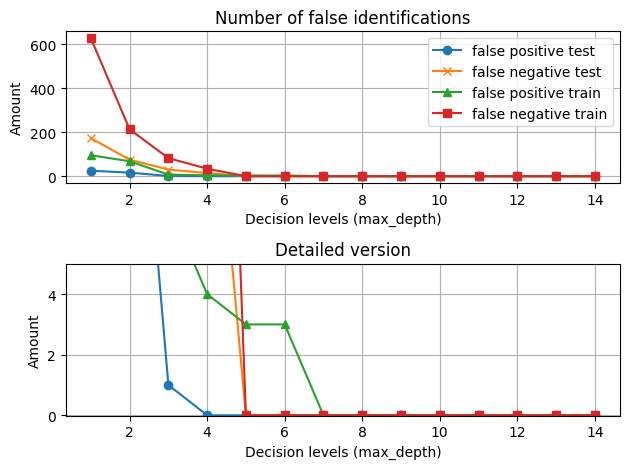

In [10]:
##################################################
# Create ColumnTransformer
##################################################

# Differentiate between category cols (for OHE) and binary cols (for OE)
cat_cols = []
bin_cols = []

# go through the side_info
# ignore the first row since it is the target
for i in range(1, side_info.shape[0]):
    si_row = side_info.iloc[i]
    if si_row['type'] == 'Categorical':
        cat_cols.append(si_row['name'])
    elif si_row['type'] == 'Binary':
        bin_cols.append(si_row['name'])
    else:
        print('Something unexpected happened. Check:', si_row['name'])

# create the two encoders we need
oe = OrdinalEncoder()
ohe = OneHotEncoder(sparse_output=False,
                    handle_unknown='warn')

# create the ColumnTransformer with both encoders
encoder = ColumnTransformer([('oe', oe, bin_cols), 
                            ('ohe', ohe, cat_cols)],
                            remainder='drop')

##################################################
# Model Parameter Tuning
##################################################

nr_false_neg = []
nr_false_pos = []
nr_false_neg_train = []
nr_false_pos_train = []

for i in range(1,15):
    # create model with depth i
    tree = DecisionTreeClassifier(max_depth=i, random_state=1)
    # create pipeline
    pipe_tree = Pipeline([('encoder', encoder),
                            ('model', tree)])

    # train the model
    pipe_tree.fit(features_train, target_train)

    # predict test data
    predict_tree = pipe_tree.predict(features_test)

    # predict training data
    predict_tree_train = pipe_tree.predict(features_train)

    # get and display the confusion matrix
    conf_matrix = confusion_matrix(target_test, predict_tree)

    # false-positive (C_01) und false-negativ (C_10)
    nr_false_neg.append(conf_matrix[1,0])
    nr_false_pos.append(conf_matrix[0,1])

    # again with training data
    conf_matrix_train = confusion_matrix(target_train, 
                                         predict_tree_train)
    nr_false_neg_train.append(conf_matrix_train[1,0])
    nr_false_pos_train.append(conf_matrix_train[0,1])

fig, axs = plt.subplots(nrows=2, ncols=1)
axs[0].plot(range(1,15), nr_false_pos, '-o', label='false positive test')
axs[0].plot(range(1,15), nr_false_neg, '-x', label='false negative test')
axs[0].plot(range(1,15), nr_false_pos_train, '-^', label='false positive train')
axs[0].plot(range(1,15), nr_false_neg_train, '-s', label='false negative train')
axs[0].set(xlabel='Decision levels (max_depth)',
           ylabel='Amount',
           title='Number of false identifications')
axs[0].grid()
axs[0].legend()

axs[1].plot(range(1,15), nr_false_pos, '-o', label='false positive test')
axs[1].plot(range(1,15), nr_false_neg, '-x', label='false negative test')
axs[1].plot(range(1,15), nr_false_pos_train, '-^', label='false positive train')
axs[1].plot(range(1,15), nr_false_neg_train, '-s', label='false negative train')
axs[1].set(xlabel='Decision levels (max_depth)',
           ylabel='Amount',
           title='Detailed version')
axs[1].set_ylim([-0.01, 5])
axs[1].grid()
plt.tight_layout()
plt.show()

Für eine perfekte Vorhersage auf den Testdaten wird lediglich ein `max_depth`von 5 benötigt. Dabei hätten wir aber noch 3 falsch negativ klassifizierte Trainingsdaten. Erstellen wir also das finale Modell mit einer Entscheidungstiefe von 7. Außerdem ist es zur Auswertung sehr hilfreich, die transformierten Features vorliegen zu haben. Das Encoding wird vom ColumnTransformer sozusagen versteckt intern vorgenommen. Wollen wir die Ergebnisse mit den Features vergleichen, müssen wir sie vorher vorbereiten.

In [11]:
# create pipeline with final tree classifier
pipe = Pipeline([('encoder', encoder), 
                 ('model', DecisionTreeClassifier(max_depth=7, 
                                                  random_state=2))])
# train model
pipe.fit(features_train, target_train)

# to better interpret the results, create transformed features
# so we know what our model is seeing
transformed_features = encoder.fit_transform(features_train)
feature_names = []
for name, transformer, columns in encoder.transformers_:
    if name == 'oe':
        cnames = columns
    elif name == 'ohe':
        cnames = transformer.get_feature_names_out(columns)
    else:
        print('Error: Check if the encoder was manipulated')
        cnames = -1
    feature_names.extend(cnames)

transformed_features = pd.DataFrame(transformed_features, columns=feature_names)
display(transformed_features.head(10))

,bruises,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
7,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


## 3. Entscheidungsbaum untersuchen

Um den Entscheidungsbaum zu verstehen ist es, meiner Meinung nach, am besten diesen als DataFrame zu handhaben. Daher erstelle ich hier einen DataFrame mit Infos zum Modell. Hier verwenden wir auch eine in `tools` ausgelagerte Methode um die Beschreibung aus der side info zu erhalten.

In [12]:
# name the model and the tree
model = pipe.named_steps['model']
tree = model.tree_
NR_NODES = tree.node_count
THRESHOLD = 0.5

# create new data frame from feature ids
df_tree = pd.DataFrame(tree.feature,columns=['feature_id'])

# One Hot Encoding transforms the features like:
# featurename_feature value
# separate those again
tree_feat_names = []
tree_feat_val_names = []
for val in tree.feature:
    if val > 0:
        # Here we need the previously encoded
        # feature names
        iname = feature_names[val]
        fname = iname.split("_", 1)[0]
        vname = iname.split("_", 1)[1]
    else:
        fname = 'no_feat'
        vname = 'no_value'
    tree_feat_names.append(fname)
    tree_feat_val_names.append(vname)

df_tree['feature'] = tree_feat_names
df_tree['feature_value'] = tree_feat_val_names

# The feature abbreviation is sufficient, but it is nice
# to know the description
descr_list = []
for i in range(NR_NODES):
    tree_feature = df_tree.loc[i, 'feature']
    tree_fvalue = df_tree.loc[i, 'feature_value']
    
    # description only for existing features
    if tree_feature != 'no_feat':
        # get description from side info
        descr = get_description(tree_feature, tree_fvalue)
        descr_list.append(descr)
    else:
        descr_list.append('no_description')
df_tree['feature_description'] = descr_list

df_tree['children_left'] = tree.children_left
df_tree['children_right'] = tree.children_right
df_tree['threshold'] = tree.threshold
df_tree['n_node_samples'] = tree.n_node_samples
df_tree['value_0'] = tree.value[:,0,0]
df_tree['value_1'] = tree.value[:,0,1]

# add the prediction to each data
# and also certainity to make it easier in the future
tree_pred = []
tree_cert = []
for i in range(NR_NODES):
    if df_tree.loc[i, 'value_1'] > THRESHOLD:
        tree_pred.append('edible')
        tree_cert.append( df_tree.loc[i, 'value_1'] )
    else:
        tree_pred.append('poisonous')
        tree_cert.append( df_tree.loc[i, 'value_0'])

df_tree['prediction'] = tree_pred
df_tree['certainity'] = tree_cert

# save the tree
df_tree.to_csv('../data/processed/decision_tree.csv')

# display the tree
display(df_tree)

,feature_id,feature,feature_value,feature_description,children_left,children_right,threshold,n_node_samples,value_0,value_1,prediction,certainity
0,26,odor,n,none,1,12,0.5,6499,0.482228,0.517772,edible,0.517772
1,51,stalk-root,c,club,2,9,0.5,3666,0.828969,0.171031,poisonous,0.828969
2,62,stalk-surface-below-ring,y,scaly,3,8,0.5,3221,0.933871,0.066129,poisonous,0.933871
3,21,odor,a,almond,4,7,0.5,3077,0.977576,0.022424,poisonous,0.977576
4,24,odor,l,anise,5,6,0.5,3042,0.988823,0.011177,poisonous,0.988823
5,-2,no_feat,no_value,no_description,-1,-1,-2.0,3008,1.000000,0.000000,poisonous,1.000000
6,-2,no_feat,no_value,no_description,-1,-1,-2.0,34,0.000000,1.000000,edible,1.000000
7,-2,no_feat,no_value,no_description,-1,-1,-2.0,35,0.000000,1.000000,edible,1.000000
8,-2,no_feat,no_value,no_description,-1,-1,-2.0,144,0.000000,1.000000,edible,1.000000
9,61,stalk-surface-below-ring,s,smooth,10,11,0.5,445,0.069663,0.930337,edible,0.930337


Dieser Data Frame beinhaltet nun alles was man wissen muss, um das Model nachzuvollziehen. Tatsächlich könnten wir mit Hilfe der Tabelle die Vorhersagen per Hand tätigen.
Um zu verstehen wie der Entscheidungsbaum Vorhersagen tätigt, und um das ganze etwas anschaulicher zu gestalten, habe ich in `tools` eine Funktion erstellt, die User input abfragt.
Hier können wir als menschlicher User uns einen Pilz vorstellen (das wäre ein Datenpunkt) und zu diesem Fragen beantworten. Nach nur wenigen Antworten erhalten wir die Vorhersage.

In [13]:
# The function gives predicted class and certainity
pred, cert = can_i_eat_it(df_tree)
print('The mushroom is with a certainity of', round(cert*100,0), '%', pred)

Please answer the following questions with yes (y) or no (n).
------------------------------
 
The odor is none
The spore-print-color is not green
The stalk-surface-below-ring is scaly
The ring-number is not two
The mushroom is with a certainity of 100.0 % poisonous


**Wichtig:** Auch hier ist zu bedenken, dass es hypothetische Datensätze sind. Das heißt nicht, dass ein Pilz der die Kriterien erfüllt auch in der Realität ungiftig ist.

Um diese Methode ohne User Input zu demonstrieren habe ich noch die Funktion `automated_questions` in `tools` erstellt. Diese nimmt einen Data Frame mit den Mushroom Daten und die ID, also welcher Datenpunkt vorhergesagt werden soll. Dann erstellt und beantwortet sie die Fragen automatisch.

In [14]:
# Just some random test id
TEST_ID = 1971

# Use the original data
df = pd.read_csv('../data/processed/all_data.csv', index_col=0)
display(df.loc[TEST_ID])
pred, cert = automated_questions(features_test, TEST_ID, df_tree)
print('The mushroom is with a certainity of', round(cert*100,0), '%', pred)

cap-shape                   f
cap-surface                 f
cap-color                   n
bruises                     f
odor                        n
gill-attachment             f
gill-spacing                w
gill-size                   b
gill-color                  h
stalk-shape                 t
stalk-root                  e
stalk-surface-above-ring    s
stalk-surface-below-ring    f
stalk-color-above-ring      w
stalk-color-below-ring      w
veil-color                  w
ring-number                 o
ring-type                   e
spore-print-color           n
population                  s
habitat                     g
poisonous                   1
Name: 1971, dtype: object

The odor is none
The spore-print-color is not green
The stalk-surface-below-ring is not scaly
The cap-surface is not grooves
The cap-shape is not conical
The gill-size is broad
The mushroom is with a certainity of 100.0 % edible


Zusätzlich können wir noch weiter Informationen aus dem Entscheidungsbaum Data Frame erlangen. Diese geben uns einen schnellen Einblick in das Modell.

In [15]:
# There is only a limited number of features considered by the model
print(f'Only {df_tree['feature'].nunique() - 1} different features considered by the model.')
print('And from these features only a fraction of their values is asked.')

q_features = df_tree['feature'].unique()
q_val_list = []
for feat in q_features:
    indices = df_tree[df_tree['feature'] == feat].index
    q_val_list.append(df_tree.loc[indices, 'feature_description'].values)

for i, q_feat in enumerate(q_features):
    if q_feat != 'no_feat':
        print(q_feat, ' : ', q_val_list[i])

Only 9 different features considered by the model.
And from these features only a fraction of their values is asked.
odor  :  ['none' 'almond' 'anise']
stalk-root  :  ['club']
stalk-surface-below-ring  :  ['scaly' 'smooth' 'scaly']
spore-print-color  :  ['green']
cap-surface  :  ['grooves']
cap-shape  :  ['conical']
gill-size  :  ['broad']
population  :  ['clustered']
ring-number  :  ['two']


Als nächstes schauen wir uns noch die Blätter an. Das sind die endgültigen Entscheidungen. In `tools` habe ich eine Funktion ausgelagert, die den Pfad der Blätter zurückverfolgt, d.h. nachvollzieht welche Fragen wie beantwortet wurden um zu der Entscheidung zu kommen. Damit könnte man im Prinzip alle möglichen Fragestellungen bearbeiten. Aber wir begnügen uns hier auf eine Auflistung der Blätter, die zu den jeweiligen Ergebnissen führen, sortiert nach Klassen, zusammen mit der Anzahl der gestellten Fragen und der Anzahl der Daten, die diesem Zweig folgten.

In [16]:
# get edible and poinsonous leafs id
id_leaf_edible = df_tree[ (df_tree['feature'] == 'no_feat') & (df_tree['prediction'] == 'edible')].index
id_leaf_poisonous = df_tree[ (df_tree['feature'] == 'no_feat') & (df_tree['prediction'] == 'poisonous')].index

# Print informations to leafs of the class edible
print('Leafs with the class edible')
print('-' * 25)
for ei in id_leaf_edible:
    paths = get_path(ei, df_tree=df_tree)
    nr_quest = len(paths['path'])
    print('Nr of questions:', nr_quest, 
          ' Nr samples', df_tree.loc[ei,'n_node_samples'])
print('-' * 25)

# Print informations to leafs of the class poisonous
print('Leafs with the class poisonous')
print('-' * 25)
for pi in id_leaf_poisonous:
    paths = get_path(pi, df_tree=df_tree)
    nr_quest = len(paths['path'])
    print('Nr of questions:', nr_quest, 
          ' Nr samples', df_tree.loc[pi,'n_node_samples'])

Leafs with the class edible
-------------------------
Nr of questions: 5  Nr samples 34
Nr of questions: 4  Nr samples 35
Nr of questions: 3  Nr samples 144
Nr of questions: 3  Nr samples 414
Nr of questions: 7  Nr samples 145
Nr of questions: 6  Nr samples 2580
Nr of questions: 4  Nr samples 13
-------------------------
Leafs with the class poisonous
-------------------------
Nr of questions: 5  Nr samples 3008
Nr of questions: 3  Nr samples 31
Nr of questions: 7  Nr samples 3
Nr of questions: 5  Nr samples 1
Nr of questions: 4  Nr samples 3
Nr of questions: 4  Nr samples 30
Nr of questions: 2  Nr samples 58


Auch wenn es noch viel mehr Möglichkeiten gibt, möchte ich das Projekt an dieser Stelle abschließen. Die Daten waren leider zu leicht vorherzusagen um die verschiedenen Modelle zu optimieren. Aber wir haben einige interessante Erkenntnisse über den Entscheidungsbaum gewonnen.